# 10. YOLOv8-seg 도입 — 모델 비교 실험 설계 및 기대 효과

> 데이터 재사용: `battery_splits/train.csv`, `battery_splits/val.csv`, `battery_splits/test.csv` <br/>(기존 분할 재사용)<br/><br/>
> 환경: Google Colab Pro (T4) — 학습 / venv_battery — 전처리·검증  <br/><br/>
> 전처리는 로컬에서, 학습은 Colab에서 실행합니다.

## 1. 왜 이 실험을 하게 됐는가

### 1-1. DeepLabV3+의 구조적 한계 — 이 데이터에 비해 너무 크다

기존 `07_re_finetune_colab.ipynb`에서 DeepLabV3+를 사용할 때 핵심적인 결정이 하나 있었습니다.

> *"학습 파라미터를 전체 40.7M 중 헤드 1.3M(3.2%)만 학습한다."*

이 결정은 **174장이라는 소규모 데이터에서 오버피팅을 막기 위한 불가피한 선택**이었습니다.  
그런데 이 제약은 동시에 모델의 표현력 상한을 낮추는 비용이기도 합니다.

| 항목 | DeepLabV3+ (현재) | 실제 필요한 것 |
|---|---|---|
| 전체 파라미터 | 40.7M | — |
| 학습된 파라미터 | 1.3M (3.2%) | 소규모 데이터 대응 |
| Backbone | ResNet-101 (freeze) | 이미지넷 사전학습만 활용 |
| 모델 파일 크기 | ~160 MB | 엣지 배포 시 부담 |
| 세그멘테이션 유형 | Semantic (픽셀 단위 분류) | Instance 수준 탐지도 유용 |

**핵심 의문**: *"처음부터 작은 모델로 학습했다면 어땠을까?"*

40.7M짜리 모델의 3.2%만 학습한 것과, 3.4M짜리 모델 전체를 학습한 것 — 실제로 어느 쪽이 이 데이터에 더 잘 맞는지는 실험 전까지는 알 수 없습니다.

### 1-2. Semantic vs Instance Segmentation — 배터리 결함 검사의 실질적 차이

DeepLabV3+는 **Semantic Segmentation**: 각 픽셀이 어느 클래스인지만 구분합니다.  
YOLOv8-seg는 **Instance Segmentation**: 결함 하나하나를 개별 객체로 인식합니다.

```
Semantic (현재):           Instance (YOLOv8-seg):
┌─────────────────┐        ┌─────────────────┐
│  [오염][오염]     │        │  결함#1 bbox+mask │
│  [오염][배경]     │   vs   │  결함#2 bbox+mask │
│  [배경][배경]     │        │  (개수/위치 추적)   │
└─────────────────┘        └─────────────────┘
```

생산 라인에서 실제로 유용한 정보는 "이 이미지에 결함이 있다/없다" 뿐 아니라  
**"결함이 몇 개, 어느 위치에 있는가"** 입니다.  
Instance Segmentation은 이 정보를 자연스럽게 제공합니다.

### 1-3. 소규모 데이터에서 작은 모델이 유리한 이유

일반화(Generalization) 관점에서 데이터 수와 모델 복잡도 사이에는 실용적인 균형점이 존재합니다.

```
오버피팅 위험
    ↑
    │                 ← DeepLabV3+ 40.7M (전체 학습 시)
    │         ← YOLOv8s 11.8M
    │   ← YOLOv8n 3.4M
    └──────────────────────────────→ 파라미터 수
           174장 데이터 기준 적정선 ↑
```

DeepLabV3+가 헤드만 학습한 이유가 바로 이 지점입니다.  
반면 YOLOv8n(3.4M)은 **전체 파라미터를 학습해도 174장에서 오버피팅 압력이 낮고**,  
Ultralytics의 자동 augmentation(mosaic, mixup, random flip, HSV 변환)이 데이터 부족을 추가로 보완될거라 예상됩니다.

## 2. 실험 설계

### 2-1. 비교 대상 모델

| 모델 | 파라미터 | 모델 크기 | 세그멘테이션 유형 | 비고 |
|---|---|---|---|---|
| **DeepLabV3+** (베이스라인) | 40.7M (학습 1.3M) | ~160 MB | Semantic | 기존 `07_re_finetune` |
| **YOLOv8n-seg** | 3.4M (전체 학습) | ~7 MB | Instance | 최소 모델 |
| **YOLOv8s-seg** | 11.8M (전체 학습) | ~24 MB | Instance | 균형점 후보 |

YOLOv8m-seg(27.3M)는 선택적으로 포함합니다. 174장 기준에서 DeepLabV3+보다 작지만 s-seg 대비 의미 있는 개선이 없을 경우 제외합니다.

### 2-2. 동일 조건 비교를 위한 설정

공정한 비교를 위해 아래 항목을 통일합니다:

- **데이터 분할**: 기존 `battery_splits/` 그대로 재사용 (train 174 / val 37 / test 38)
- **평가 지표**: Instance Recall (결함 14장 기준), False Positive 수 (정상품 24장 기준), 추론 latency
- **후처리**: 기존 `min_conf=0.70` 동일 적용 (YOLO confidence threshold)
- **환경**: Colab Pro T4, 동일 random seed


### 2-3. 데이터 포맷 변환 — JSON 폴리곤 → YOLO 세그멘테이션

기존 `02_preprocess.ipynb`의 JSON 폴리곤 마스크를 YOLO `.txt` 포맷으로 변환합니다.

```
기존 (DeepLabV3+):             YOLO 세그멘테이션 포맷:
battery_mask/xxx.png           labels/xxx.txt
[uint8 마스크 이미지]           <class_id> <x1> <y1> <x2> <y2> ...
                               (정규화 좌표, 클래스당 한 줄)
```

클래스 인덱스 매핑:

| 클래스 | 기존 마스크 값 | YOLO class_id |
|---|---|---|
| background | 0 | (라벨 없음) |
| Pollution | 1 | 0 |
| Damaged | 2 | 1 |

---

# 0. 환경 설정

In [1]:
import sys, torch, cv2, ultralytics, onnxruntime as ort
from pathlib import Path

print(f"Python      : {sys.version}")
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA 사용가능: {torch.cuda.is_available()}")       # Colab: True
print(f"Ultralytics : {ultralytics.__version__}")
print(f"OpenCV      : {cv2.__version__}")
print(f"ORT 제공자  : {ort.get_available_providers()}")

Python      : 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
PyTorch     : 2.11.0+cpu
CUDA 사용가능: False
Ultralytics : 8.4.62
OpenCV      : 4.11.0
ORT 제공자  : ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


# 1. 경로 설정

In [2]:
from pathlib import Path
import pandas as pd

# ── 로컬(Mac) 실행 시 ──────────────────────────────────────────
PROJECT   = Path(r'D:\02.study\part4_wj\Battery\Battery_Project')

# ── Colab 실행 시 (Drive 마운트 후) ───────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# PROJECT = Path('/content/drive/MyDrive/battery-mlops-vision')

IMG_DIR   = PROJECT / 'battery_image'    # gitignore 대상 (원본 이미지)
LABEL_DIR = PROJECT / 'battery_label'    # gitignore 대상 (원본 JSON)
SPLIT_DIR = PROJECT / 'battery_splits'

YOLO_DIR  = PROJECT / 'yolo_dataset'     # 새로 생성할 YOLO 포맷 데이터셋
MODEL_DIR = PROJECT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

# 분할 CSV 로드
train_df = pd.read_csv(SPLIT_DIR / 'train_meta.csv')  # columns: name, label
val_df   = pd.read_csv(SPLIT_DIR / 'val_meta.csv')
test_df  = pd.read_csv(SPLIT_DIR / 'test_meta.csv')

print(f"train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")
print(train_df['label'].value_counts())

train: 174 | val: 37 | test: 38
label
clean        112
both          32
pollution     30
Name: count, dtype: int64


## 1-1. JSON 구조 확인

YOLO 모델을 쓰기 전 먼저 확인해야하는 필수 전처리 절차입니다.

In [3]:
import json

# 샘플 1개의 JSON 구조 출력
sample_name = train_df['name'].iloc[0]
json_files = list(LABEL_DIR.glob(f"{sample_name}*.json"))

if not json_files:
    # 일부 AI Hub 데이터는 이미지당 1개 JSON이 아닌 통합 JSON일 수 있음
    json_files = list(LABEL_DIR.glob("*.json"))
    print(f"통합 JSON 발견: {json_files}")
else:
    with open(json_files[0], encoding='utf-8') as f:
        data = json.load(f)
    
    print("=== JSON 최상위 키 ===")
    print(list(data.keys()))
    
    # COCO 스타일인 경우 (images + annotations + categories)
    if 'annotations' in data:
        print("\n=== annotations[0] ===")
        print(json.dumps(data['annotations'][0], indent=2, ensure_ascii=False))
        print("\n=== categories ===")
        print(data.get('categories', '없음'))
    
    # 개별 이미지 JSON인 경우
    elif 'shapes' in data:
        print("\n=== shapes[0] (LabelMe 형식) ===")
        print(json.dumps(data['shapes'][0], indent=2, ensure_ascii=False))
    
    else:
        print("\n=== 전체 구조 (첫 500자) ===")
        print(str(data)[:500])

=== JSON 최상위 키 ===
['data_info', 'swelling', 'defects', 'image_info']

=== 전체 구조 (첫 500자) ===
{'data_info': {'data_type': 'rgb', 'battery_ids': 1154, 'application': '산업', 'type': 'cell', 'form': 'cylindrical', 'date': '2023.10.10', 'place': 'KTR', 'distance': 17, 'degree': [40, 15], 'roi': None}, 'swelling': {'swelling': False, 'battery_outline': [941.0, 256.9, 977.3, 261.0, 1017.2, 274.9, 1046.6, 301.5, 1061.1, 334.8, 1054.0, 902.0, 1044.0, 929.0, 1026.0, 949.0, 1000.0, 965.0, 966.0, 974.0, 920.0, 970.0, 891.0, 958.0, 867.0, 938.0, 853.0, 912.0, 805.0, 376.0, 805.0, 331.0, 819.0, 303.0,


## 1-2. JSON → YOLO 세그멘테이션 포맷 변환

> 클래스 매핑: Pollution=0, Damaged=1 (background는 라벨 없음)

In [4]:
import numpy as np
import shutil

# ── 클래스 매핑 ───────────────────────────────────────────────
# AI Hub 카테고리 ID → YOLO class_id
# category_id 1 = Pollution → 0
# category_id 2 = Damaged   → 1
CAT_MAP = {1: 0, 2: 1}
CLASS_NAMES = ['Pollution', 'Damaged']


def polygon_to_yolo(points: list, img_w: int, img_h: int) -> str:
    """
    [[x1,y1],[x2,y2],...] 또는 [x1,y1,x2,y2,...] 형태의 폴리곤을
    YOLO 정규화 좌표 문자열로 변환합니다.
    """
    if isinstance(points[0], (list, tuple)):
        flat = [coord for pt in points for coord in pt]
    else:
        flat = points

    coords = []
    for i in range(0, len(flat) - 1, 2):
        x_norm = round(flat[i]     / img_w, 6)
        y_norm = round(flat[i + 1] / img_h, 6)
        # 클리핑: 이미지 경계 밖 폴리곤 방지
        x_norm = min(max(x_norm, 0.0), 1.0)
        y_norm = min(max(y_norm, 0.0), 1.0)
        coords.extend([x_norm, y_norm])

    return ' '.join(map(str, coords))


def convert_coco_json_to_yolo(json_path: Path, out_label_dir: Path):
    """
    COCO 스타일 통합 JSON → 이미지별 .txt 라벨 파일 생성
    (AI Hub 배터리 데이터의 일반적 형식 대응)
    """
    with open(json_path) as f:
        data = json.load(f)

    # image_id → (file_name, width, height) 매핑
    img_info = {
        img['id']: (img['file_name'], img['width'], img['height'])
        for img in data['images']
    }

    # image_id → annotations 그룹핑
    from collections import defaultdict
    ann_by_img = defaultdict(list)
    for ann in data['annotations']:
        ann_by_img[ann['image_id']].append(ann)

    out_label_dir.mkdir(parents=True, exist_ok=True)
    converted = 0

    for img_id, anns in ann_by_img.items():
        file_name, img_w, img_h = img_info[img_id]
        stem = Path(file_name).stem
        txt_path = out_label_dir / f"{stem}.txt"

        lines = []
        for ann in anns:
            cat_id = ann['category_id']
            if cat_id not in CAT_MAP:
                continue  # background 등 무시
            yolo_cls = CAT_MAP[cat_id]

            # segmentation은 [[x1,y1,x2,y2,...]] 또는 [[x,y],[x,y],...]
            for seg in ann['segmentation']:
                poly_str = polygon_to_yolo(seg, img_w, img_h)
                lines.append(f"{yolo_cls} {poly_str}")

        txt_path.write_text('\n'.join(lines))
        converted += 1

    print(f"변환 완료: {converted}개 이미지 → {out_label_dir}")


def convert_individual_json_to_yolo(name: str, label_dir: Path,
                                     img_dir: Path, out_label_dir: Path):
    """
    이미지별 개별 JSON → YOLO .txt
    (AI Hub에서 이미지당 JSON 1개로 배포하는 경우)
    """
    import cv2 as _cv2

    json_candidates = list(label_dir.glob(f"{name}*.json"))
    if not json_candidates:
        return  # 라벨 없는 이미지 (정상품) → .txt 생성 안 함

    img = _cv2.imread(str(img_dir / f"{name}.png"))
    if img is None:
        img = _cv2.imread(str(img_dir / f"{name}.jpg"))
    img_h, img_w = img.shape[:2]

    lines = []
    for jp in json_candidates:
        with open(jp) as f:
            data = json.load(f)

        # LabelMe / AI Hub 개별 JSON 형식
        shapes = data.get('shapes', data.get('annotations', []))
        for shape in shapes:
            label = shape.get('label', shape.get('category_id', ''))
            
            # 라벨명 → class_id 변환
            if isinstance(label, int):
                if label not in CAT_MAP:
                    continue
                cls_id = CAT_MAP[label]
            else:
                label_lower = str(label).lower()
                if 'pollution' in label_lower:
                    cls_id = 0
                elif 'damaged' in label_lower or 'damage' in label_lower:
                    cls_id = 1
                else:
                    continue

            pts = shape.get('points', shape.get('segmentation', []))
            if pts:
                poly_str = polygon_to_yolo(pts, img_w, img_h)
                lines.append(f"{cls_id} {poly_str}")

    if lines:
        out_label_dir.mkdir(parents=True, exist_ok=True)
        (out_label_dir / f"{name}.txt").write_text('\n'.join(lines))

## 1-3. YOLO 데이터셋 디렉토리 구성

In [11]:
import shutil

def build_yolo_dataset(split_df: pd.DataFrame, split_name: str,
                        img_dir: Path, label_dir: Path, yolo_dir: Path,
                        is_coco_json: bool = False):
    """
    battery_splits CSV 기준으로 YOLO images/ + labels/ 폴더 구성
    - 이미지: 심볼릭 링크 (복사 대신 공간 절약)
    - 라벨: 이미 변환된 .txt 파일 링크
    """
    out_img   = yolo_dir / 'images' / split_name
    out_label = yolo_dir / 'labels' / split_name
    out_img.mkdir(parents=True, exist_ok=True)
    out_label.mkdir(parents=True, exist_ok=True)

    for _, row in split_df.iterrows():
        name = row['name']

        # 이미지 심볼릭 링크
        for ext in ['.png', '.jpg']:
            src_img = img_dir / f"{name}{ext}"
            if src_img.exists():
                dst = out_img / src_img.name
                try:
                    if not dst.exists():
                        dst.symlink_to(src_img.resolve())
                except OSError:
                    shutil.copy(src_img, dst)
            break

        # 라벨 파일 (결함 없는 정상품은 빈 .txt)
        src_lbl = label_dir / f"{name}.txt"
        dst_lbl = out_label / f"{name}.txt"
        if src_lbl.exists():
            if not dst_lbl.exists():
                try:
                    dst_lbl.symlink_to(src_lbl.resolve())
                except OSError:
                    shutil.copy(src_lbl, dst_lbl)
        else:
            # 정상품: 빈 파일 = 결함 없음
            dst_lbl.write_text('')

    print(f"{split_name}: {len(split_df)}장 구성 완료")
    
    
NAME_MAP = {'Pollution': 0, 'Damaged': 1}
def convert_aihub_json_to_yolo(json_path: Path, out_label_dir: Path):
    """
    AI Hub 배터리 JSON(defects[].points 폴리곤) → YOLO seg .txt
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 1. 이미지 해상도 추출 (정규화용)
    img_info = data.get('image_info', {})
    img_w, img_h = img_info.get('width',0), img_info.get('height', 0)
    if not img_w or not img_h:
        return  # 해상도 정보가 없으면 YOLO 정규화가 불가능하므로 스킵

    # 2. 결함(defects) 데이터 추출 및 변환
    yolo_lines = []

    for defect in (data.get('defects') or []):
        cls_id = NAME_MAP.get(defect.get('name'))
        if cls_id is None:
            continue
        
        point = defect.get('points', [])
        if len(point) < 6: # 폴리곤 최소 3개 점
            continue

        poly_str = polygon_to_yolo(point, img_w, img_h)
        yolo_lines.append(f"{cls_id} {poly_str}")
        
        # 결함 있을 때에만 파일 생성 (정상품은 build 단계에서 빈 .txt 처리)
        if yolo_lines:
            out_label_dir.mkdir(parents=True, exist_ok=True)
            (out_label_dir / f"{json_path.stem}.txt").write_text('\n'.join(yolo_lines), encoding='utf-8')

    
    # 3. 변환된 라벨 저장
    out_txt_path = out_label_dir / f"{json_path.stem}.txt"
    with open(out_txt_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(yolo_lines))

# ── 실행 ─────────────────────────────────────────────────────
CONVERTED_LABEL = YOLO_DIR / '_converted_labels'
CONVERTED_LABEL.mkdir(parents=True, exist_ok=True)

# JSON 형식 확인 후 아래 둘 중 하나 선택:
all_json_files = list(LABEL_DIR.glob("*.json"))
print(f"총 {len(all_json_files)}개의 JSON 파일 변환 시작...")

for jf in all_json_files:
    convert_aihub_json_to_yolo(jf, CONVERTED_LABEL)

print("JSON -> YOLO txt 변환 완료")

# YOLO 폴더 구조 빌드
for df, split in [(train_df, 'train'), (val_df, 'val'), (test_df, 'test')]:
    build_yolo_dataset(df, split, IMG_DIR, CONVERTED_LABEL, YOLO_DIR)
    
print("\n YOLO 데이터셋 구축이 완료되었습니다.")

총 249개의 JSON 파일 변환 시작...
JSON -> YOLO txt 변환 완료
train: 174장 구성 완료
val: 37장 구성 완료
test: 38장 구성 완료

 YOLO 데이터셋 구축이 완료되었습니다.


## 1-4. dataset.yaml 생성

In [12]:
import yaml

dataset_yaml = {
    'path': str(YOLO_DIR.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc': 2,
    'names': CLASS_NAMES,   # ['Pollution', 'Damaged']
}

yaml_path = YOLO_DIR / 'battery.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, allow_unicode=True)

print(f"dataset.yaml 저장: {yaml_path}")
print(yaml.dump(dataset_yaml, default_flow_style=False, allow_unicode=True))

dataset.yaml 저장: D:\02.study\part4_wj\Battery\Battery_Project\yolo_dataset\battery.yaml
names:
- Pollution
- Damaged
nc: 2
path: D:\02.study\part4_wj\Battery\Battery_Project\yolo_dataset
test: images/test
train: images/train
val: images/val



## 1-5. 라벨 검증

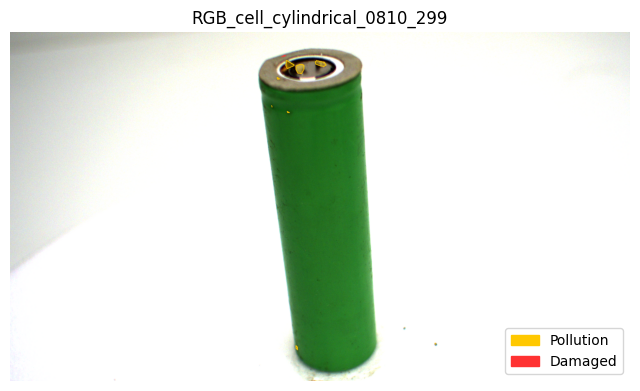

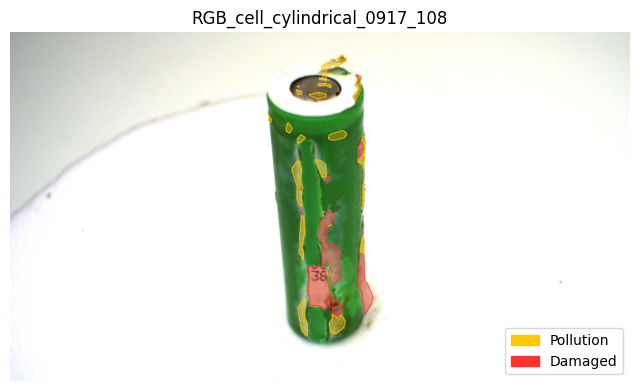

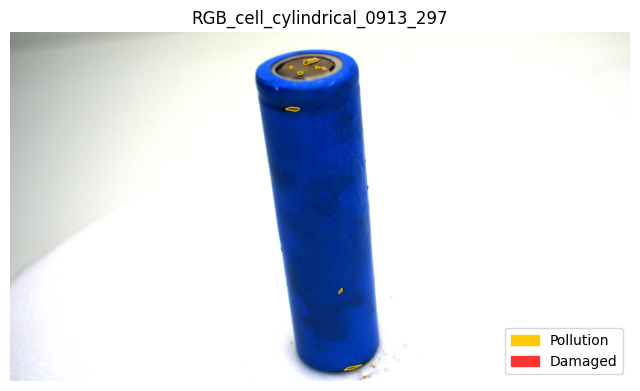

In [13]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PALETTE = {0: (255, 200, 0), 1: (255, 50, 50)}   # Pollution=노랑, Damaged=빨강


def visualize_yolo_label(name: str, split: str = 'train'):
    img_path   = YOLO_DIR / 'images' / split / f"{name}.png"
    label_path = YOLO_DIR / 'labels' / split / f"{name}.txt"

    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()

    if label_path.stat().st_size == 0:
        print(f"[{name}] 정상품 — 라벨 없음")
    else:
        for line in label_path.read_text().strip().split('\n'):
            parts = line.split()
            cls_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            pts = np.array([(coords[i]*w, coords[i+1]*h)
                            for i in range(0, len(coords), 2)], np.int32)
            color = PALETTE.get(cls_id, (128, 128, 128))
            cv2.fillPoly(overlay, [pts], color)
            cv2.polylines(img, [pts], True, color, 2)

    blended = cv2.addWeighted(overlay, 0.35, img, 0.65, 0)
    plt.figure(figsize=(8, 6))
    plt.imshow(blended)
    patches = [mpatches.Patch(color=np.array(c)/255, label=CLASS_NAMES[i])
               for i, c in PALETTE.items()]
    plt.legend(handles=patches, loc='lower right')
    plt.title(name)
    plt.axis('off')
    plt.show()


# 결함 있는 샘플 3개 확인
defect_samples = train_df[train_df['label'] != 'clean']['name'].head(3)
for name in defect_samples:
    visualize_yolo_label(name)

# 2. YOLOv8n-seg 학습 (Colab T4)

In [ ]:
from ultralytics import YOLO

# ── YOLOv8n-seg: 경량 모델 ────────────────────────────────────
model_n = YOLO('yolov8n-seg.pt')   # COCO 사전학습 가중치 자동 다운로드

results_n = model_n.train(
    data=str(yaml_path),
    epochs=150,
    imgsz=640,
    batch=16,             # T4 메모리 기준 (OOM 시 8로 줄이기)
    patience=30,          # Early stopping
    seed=42,
    device=0,             # GPU (Colab: 0, Mac: 'mps', CPU: 'cpu')
    project=str(MODEL_DIR),
    name='yolov8n_seg',
    exist_ok=True,
    # 소규모 데이터 대응 augmentation 강화
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    flipud=0.3,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    # 클래스 불균형 대응 (Damaged 픽셀 비율 0.12%)
    cls=0.3,              # classification loss weight 낮춤
)

print(f"YOLOv8n-seg 학습 완료: {results_n.save_dir}")

# 3. YOLOv8s-seg 학습 (Colab T4)

In [ ]:
# ── YOLOv8s-seg: 균형점 모델 ─────────────────────────────────
model_s = YOLO('yolov8s-seg.pt')

results_s = model_s.train(
    data=str(yaml_path),
    epochs=150,
    imgsz=640,
    batch=8,              # s-seg는 n-seg보다 메모리 더 사용
    patience=30,
    seed=42,
    device=0,
    project=str(MODEL_DIR),
    name='yolov8s_seg',
    exist_ok=True,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    flipud=0.3,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    cls=0.3,
)

print(f"YOLOv8s-seg 학습 완료: {results_s.save_dir}")